<a href="https://colab.research.google.com/github/samarreguigui/summarization/blob/main/VERBOS~2_IPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verbosity Bias — FineSurE on all 6 papers

Pipeline: PDF → clean text → keyfact extraction → FineSurE Task 1 (fact-checking) + Task 2 (keyfact alignment) → scores + per-sentence error analysis.

**Key features:**
- Idempotent setup: works after a Colab disconnect without re-installing manually.
- Per-call cache: identical prompts never re-hit the API. Re-runs are free.
- One master CSV across all papers (`scores_master.csv`).
- One per-sentence error CSV with GPT-4's reasons (`faithfulness_per_sentence.csv`).

**Run order:** top to bottom. No need to change anything mid-run.

## 1. Setup — install + clone (idempotent)

In [1]:
import importlib, subprocess, os, sys

PKGS = {
    'pymupdf': 'fitz',       # PDF reader; import name differs
    'tiktoken': 'tiktoken',
    'nltk': 'nltk',
    'pandas': 'pandas',
    'tqdm': 'tqdm',
    'openai': 'openai',
    'httpx': 'httpx',
    'matplotlib': 'matplotlib',
}
for pip_name, import_name in PKGS.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f'installing {pip_name}...')
        subprocess.check_call(['pip', '-q', 'install', '--upgrade', pip_name])

# NLTK punkt for sentence splitting
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Clone FineSurE if missing
if not os.path.isdir('/content/FineSurE-ACL24'):
    print('cloning FineSurE-ACL24...')
    subprocess.check_call(['git', 'clone', '-q', 'https://github.com/DISL-Lab/FineSurE-ACL24.git'])
sys.path.insert(0, '/content/FineSurE-ACL24/finesure')

print('Setup done.')

installing pymupdf...
cloning FineSurE-ACL24...
Setup done.


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration

Adjust paths if your Drive layout differs.

In [3]:
from pathlib import Path

# --- Paths in Drive ---
PROJECT     = Path('/content/drive/MyDrive/summarization')
PAPER_DIR   = PROJECT / 'data' / 'paper'
SUMMARY_DIR = PROJECT / 'data' / 'different summaries size'
KEY_FILE    = Path('/content/drive/MyDrive/Master thesis/openrouter_key.txt')

# --- Local Colab working folders (ephemeral until cell 9 copies to Drive) ---
WORK_DIR     = Path('/content/work')
CACHE_DIR    = WORK_DIR / 'cache'
RESULTS_DIR  = WORK_DIR / 'results'
ARTICLES_DIR = WORK_DIR / 'articles'
KEYFACTS_DIR = WORK_DIR / 'keyfacts'
FIGURES_DIR  = WORK_DIR / 'figures'
for d in [WORK_DIR, CACHE_DIR, RESULTS_DIR, ARTICLES_DIR, KEYFACTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Which papers to process ---
ALL_PAPER_IDS = ['01', '02', '03', '04', '05', '06']

# --- Model & API ---
MODEL          = 'openai/gpt-4o-2024-05-13'   # FineSurE script default
# Alternatives (uncomment to match the paper exactly):
# MODEL = 'openai/gpt-4-1106-preview'
# MODEL = 'openai/gpt-3.5-turbo-0125'
OPENROUTER_URL = 'https://openrouter.ai/api/v1'
TEMPERATURE    = 0.0

print('Project root:', PROJECT)
print('Papers      :', ALL_PAPER_IDS)
print('Model       :', MODEL)

Project root: /content/drive/MyDrive/summarization
Papers      : ['01', '02', '03', '04', '05', '06']
Model       : openai/gpt-4o-2024-05-13


## 4. Helpers — PDF → text, sentence split, token count

In [4]:
import fitz, re, hashlib, json, os, time, ast
from typing import List
import tiktoken
from nltk.tokenize import sent_tokenize

ENC = tiktoken.get_encoding('cl100k_base')

def n_tokens(text: str) -> int:
    return len(ENC.encode(text))

def read_pdf(path: Path) -> str:
    doc = fitz.open(path)
    text = '\n'.join(page.get_text() for page in doc)
    doc.close()
    return text

def clean_article(raw: str) -> str:
    cut = re.split(r'\n\s*(References|REFERENCES|Bibliography)\b', raw, maxsplit=1)[0]
    cut = re.sub(r'[ \t]+', ' ', cut)
    cut = re.sub(r'\n{3,}', '\n\n', cut)
    return cut.strip()

def clean_summary(raw: str) -> str:
    return re.sub(r'\s+', ' ', raw).strip()

def sentences_of(text: str) -> List[str]:
    return [s.strip() for s in sent_tokenize(text) if s.strip()]

def find_article(paper_id: str) -> Path:
    matches = sorted(PAPER_DIR.glob(f'{paper_id}_*.pdf'))
    assert matches, f'No article PDF for paper {paper_id} in {PAPER_DIR}'
    return matches[0]

def find_summaries(paper_id: str):
    items = []
    for p in sorted(SUMMARY_DIR.glob(f'{paper_id}_*.pdf')):
        name = p.stem.lower()
        for size in ['verylong', 'long', 'medium', 'short']:
            if size in name:
                items.append((size, p.stem, p))
                break
    return items

print('Helpers ready.')

Helpers ready.


## 5. OpenRouter client + cached call

Each prompt is hashed. Identical prompts never re-hit the API.

In [5]:
import openai

API_KEY = KEY_FILE.read_text().strip()
client = openai.OpenAI(api_key=API_KEY, base_url=OPENROUTER_URL)

def _cache_key(model, prompt, temperature):
    h = hashlib.sha256()
    h.update(model.encode()); h.update(b'|')
    h.update(str(temperature).encode()); h.update(b'|')
    h.update(prompt.encode())
    return h.hexdigest()[:24]

def get_response(prompt, model=None, temperature=None, max_retries=3):
    model = model or MODEL
    temperature = TEMPERATURE if temperature is None else temperature
    key = _cache_key(model, prompt, temperature)
    cache_file = CACHE_DIR / f'{key}.json'
    if cache_file.exists():
        return json.loads(cache_file.read_text())['response']
    last_err = None
    for attempt in range(max_retries):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=temperature,
            )
            text = r.choices[0].message.content
            cache_file.write_text(json.dumps({
                'model': model, 'temperature': temperature,
                'prompt': prompt, 'response': text,
            }))
            return text
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)
    raise RuntimeError(f'Failed after {max_retries} retries: {last_err}')

print('OpenRouter client ready. Cache dir:', CACHE_DIR)

OpenRouter client ready. Cache dir: /content/work/cache


## 6. Keyfact extraction prompt + parser

The FineSurE repo doesn't ship a keyfact-extraction script (only Task 1 and Task 2). This prompt is modeled stylistically on the paper's other prompts.

In [6]:
KEYFACT_PROMPT = '''
You will receive a transcript. Your task is to extract a list of key facts from the transcript.

A key fact is a short, atomic, factual statement that captures a single piece of important information stated in the transcript. Each key fact should be a complete, standalone sentence.

Instruction:
First, read the transcript carefully.
Second, identify between 10 and 16 distinct key facts that together capture the most important content of the transcript.
Third, write each key fact as a short standalone sentence in plain English.

Provide your answer in JSON format. The answer should be a list of dictionaries whose key is "key fact":
[{"key fact": "first key fact"}, {"key fact": "second key fact"}, {"key fact": "third key fact"}]

Transcript:
%s
'''

def parse_keyfacts(output: str):
    try:
        start = output.find('['); end = output.rfind(']')
        items = ast.literal_eval(output[start:end+1])
        return [d['key fact'].strip() for d in items if 'key fact' in d]
    except Exception as e:
        print('keyfact parse error:', e)
        return []

print('Keyfact prompt loaded.')

Keyfact prompt loaded.


## 7. Run FineSurE on all 6 papers

For each paper:
1. Read + clean article.
2. Extract (or load) keyfact list, frozen per paper.
3. For each summary size variant: Task 1 (fact-checking) → faithfulness; Task 2 (alignment) → completeness + conciseness.
4. Persist per-summary JSONs and accumulate one row per summary.

Re-runs are cheap: any (paper × summary) already in `results/task*__*.json` is skipped. The first full run costs ~$2 on OpenRouter.

In [7]:
import pandas as pd
from utils import (
    get_fact_checking_prompt, parsing_llm_fact_checking_output, compute_faithfulness_percentage_score,
    get_keyfact_alighment_prompt, parsing_llm_keyfact_alighment_output,
    compute_completeness_percentage_score, compute_conciseness_percentage_score,
)

master_rows = []
for pid in ALL_PAPER_IDS:
    print(f'\n=== Paper {pid} ===')

    # Article
    article_path = find_article(pid)
    article_text = clean_article(read_pdf(article_path))
    (ARTICLES_DIR / f'{pid}.txt').write_text(article_text)
    print(f'  article: {article_path.name}  ({n_tokens(article_text):,} tokens)')

    # Keyfacts (cached per paper)
    kf_file = KEYFACTS_DIR / f'{pid}.json'
    if kf_file.exists():
        keyfacts = json.loads(kf_file.read_text())['key_facts']
        print(f'  keyfacts loaded: {len(keyfacts)}')
    else:
        raw = get_response(KEYFACT_PROMPT % article_text)
        keyfacts = parse_keyfacts(raw)
        kf_file.write_text(json.dumps({'doc_id': pid, 'key_facts': keyfacts}, indent=2))
        print(f'  keyfacts extracted: {len(keyfacts)}')

    # Summaries
    summaries = find_summaries(pid)
    if not summaries:
        print(f'  WARN: no summaries found for paper {pid}')
        continue

    for size, label, path in summaries:
        summary_text = clean_summary(read_pdf(path))
        sents = sentences_of(summary_text)

        # --- Task 1 ---
        t1_f = RESULTS_DIR / f'task1__{label}.json'
        if t1_f.exists():
            t1 = json.loads(t1_f.read_text())
        else:
            raw = get_response(get_fact_checking_prompt(input=article_text, sentences=sents))
            pl, pt = parsing_llm_fact_checking_output(raw)
            if not pl:
                print(f'  WARN: empty parse task1 {label}')
                continue
            t1 = {
                'summary_label': label, 'size': size, 'n_sentences': len(sents),
                'pred_labels': pl, 'pred_types': pt,
                'faithfulness': compute_faithfulness_percentage_score(pl),
                'raw': raw,
            }
            t1_f.write_text(json.dumps(t1, indent=2))

        # --- Task 2 ---
        t2_f = RESULTS_DIR / f'task2__{label}.json'
        if t2_f.exists():
            t2 = json.loads(t2_f.read_text())
        else:
            raw = get_response(get_keyfact_alighment_prompt(keyfacts=keyfacts, sentences=sents))
            pl2, matched = parsing_llm_keyfact_alighment_output(raw)
            if not pl2:
                print(f'  WARN: empty parse task2 {label}')
                continue
            t2 = {
                'summary_label': label, 'size': size, 'n_sentences': len(sents),
                'keyfact_labels': pl2, 'matched_lines': matched,
                'n_keyfacts': len(keyfacts), 'n_keyfacts_covered': sum(pl2),
                'completeness': compute_completeness_percentage_score(pl2),
                'conciseness': compute_conciseness_percentage_score(matched, len(sents)),
                'raw': raw,
            }
            t2_f.write_text(json.dumps(t2, indent=2))

        master_rows.append({
            'paper_id': pid, 'summary_label': label, 'size': size,
            'realised_tokens': n_tokens(summary_text), 'n_sentences': len(sents),
            'faithfulness': t1['faithfulness'],
            'completeness': t2['completeness'], 'conciseness': t2['conciseness'],
            'n_keyfacts_total': t2['n_keyfacts'],
            'n_keyfacts_covered': t2['n_keyfacts_covered'],
        })
        print(f"  {label}  sents={len(sents)}  faith={t1['faithfulness']:.2f}  comp={t2['completeness']:.2f}  conc={t2['conciseness']:.2f}")

master_df = pd.DataFrame(master_rows).sort_values(['paper_id','realised_tokens']).reset_index(drop=True)
master_df.to_csv(RESULTS_DIR / 'scores_master.csv', index=False)
print('\nMaster CSV saved:', RESULTS_DIR / 'scores_master.csv')
master_df


=== Paper 01 ===
  article: 01_LLMs instead of Human Judge.pdf  (7,250 tokens)
  keyfacts extracted: 16
  01_sum1_medium  sents=18  faith=1.00  comp=0.88  conc=0.61
  01_sum1_short  sents=8  faith=1.00  comp=0.56  conc=0.50
  01_sum_long_gen_hum  sents=21  faith=0.00  comp=0.00  conc=0.00

=== Paper 02 ===
  article: 02_On the Dangers of Stochastic Parrots.pdf  (15,277 tokens)
  keyfacts extracted: 16
  02_sum1_long_gen_hum  sents=45  faith=1.00  comp=0.94  conc=0.40
  02_sum1_medium_gen_hum  sents=23  faith=0.91  comp=0.75  conc=0.39
  02_sum1_short  sents=13  faith=1.00  comp=0.69  conc=0.85

=== Paper 03 ===
  article: 03_ Models Be Tricked by Language Illusions.pdf  (8,762 tokens)
  keyfacts extracted: 16
  03_sum2_short  sents=11  faith=0.73  comp=0.50  conc=0.64
  03_sum_medium  sents=17  faith=0.92  comp=0.56  conc=0.53
  03_sum_verylong_gen_hum  sents=138  faith=1.00  comp=1.00  conc=0.21

=== Paper 04 ===
  article: 04_Grounding Semantics in Olfactory Perception.pdf  (4,293 t

,paper_id,summary_label,size,realised_tokens,n_sentences,faithfulness,completeness,conciseness,n_keyfacts_total,n_keyfacts_covered
0,01,01_sum1_short,short,190,8,1.000000,0.5625,0.500000,16,9
1,01,01_sum1_medium,medium,435,18,1.000000,0.8750,0.611111,16,14
2,01,01_sum_long_gen_hum,long,543,21,0.000000,0.0000,0.000000,16,0
3,02,02_sum1_short,short,306,13,1.000000,0.6875,0.846154,16,11
4,02,02_sum1_medium_gen_hum,medium,662,23,0.913043,0.7500,0.391304,16,12
5,02,02_sum1_long_gen_hum,long,1215,45,1.000000,0.9375,0.400000,16,15
6,03,03_sum2_short,short,309,11,0.727273,0.5000,0.636364,16,8
7,03,03_sum_medium,medium,362,17,0.916667,0.5625,0.529412,16,9
8,03,03_sum_verylong_gen_hum,verylong,3319,138,1.000000,1.0000,0.210145,16,16
9,04,04_sum1_short,short,212,6,1.000000,0.3125,0.500000,16,5


## 8. Per-sentence faithfulness inspection

One row per summary sentence across all papers, with GPT-4's reason for each error. Open `faithfulness_per_sentence.csv` in Excel to browse / sort / filter.

In [10]:
import json, re, ast

def extract_reasons(raw):
    raw = raw.replace('```json','').replace('```','')
    m = re.search(r'\[.*\]', raw, flags=re.DOTALL)
    if not m: return []
    try:
        items = ast.literal_eval(m.group(0))
        return [it.get('reason','') for it in items]
    except Exception:
        return []

rows = []
for jf in sorted(RESULTS_DIR.glob('task1__*.json')):
    r = json.loads(jf.read_text())
    label, size = r['summary_label'], r['size']
    pid = label[:2]
    pdf = next(SUMMARY_DIR.glob(f'{label}.pdf'), None)
    if not pdf: continue
    sents = sentences_of(clean_summary(read_pdf(pdf)))
    reasons = extract_reasons(r.get('raw',''))
    for i, sent in enumerate(sents):
        lab = r['pred_labels'][i] if i < len(r['pred_labels']) else None
        typ = r['pred_types'][i]  if i < len(r['pred_types'])  else None
        rea = reasons[i]          if i < len(reasons)          else ''
        rows.append({
            'paper_id': pid, 'summary_label': label, 'size': size,
            'sentence_idx': i+1, 'sentence': sent,
            'error_label': lab, 'error_type': typ, 'reason': rea,
        })

errors_df = pd.DataFrame(rows)
errors_df.to_csv(RESULTS_DIR / 'faithfulness_per_sentence.csv', index=False)
flagged = errors_df[errors_df['error_label'] == 1]
print(f'Total summary sentences scored: {len(errors_df)}')
print(f'Flagged with some error       : {len(flagged)}')
print(f'CSV saved to                  : {RESULTS_DIR / "faithfulness_per_sentence.csv"}')
print()
print('--- Flagged sentences ---')
flagged

Total summary sentences scored: 610
Flagged with some error       : 30
CSV saved to                  : /content/work/results/faithfulness_per_sentence.csv

--- Flagged sentences ---


,paper_id,summary_label,size,sentence_idx,sentence,error_label,error_type,reason
26,01,01_sum_long_gen_hum,long,1,"Climbing towards NLU (Bender & Koller, 2020) a...",1.0,out-of-context error,This statement is not present in the transcript.
27,01,01_sum_long_gen_hum,long,2,Their core claims: The central argument.,1.0,out-of-context error,This statement is not present in the transcript.
28,01,01_sum_long_gen_hum,long,3,Language modeling is pure string prediction.,1.0,out-of-context error,This statement is not present in the transcript.
29,01,01_sum_long_gen_hum,long,4,Since the training signal contains only form a...,1.0,out-of-context error,This statement is not present in the transcript.
30,01,01_sum_long_gen_hum,long,5,"The recent successes of BERT and GPT-2 on ""mea...",1.0,out-of-context error,This statement is not present in the transcript.
31,01,01_sum_long_gen_hum,long,6,The octopus thought experiment.,1.0,out-of-context error,This statement is not present in the transcript.
32,01,01_sum_long_gen_hum,long,7,A hyper-intelligent octopus eavesdrops on two ...,1.0,out-of-context error,This statement is not present in the transcript.
33,01,01_sum_long_gen_hum,long,8,"It can imitate small talk convincingly, but wh...",1.0,out-of-context error,This statement is not present in the transcript.
34,01,01_sum_long_gen_hum,long,9,"When humans find such output meaningful, it's ...",1.0,out-of-context error,This statement is not present in the transcript.
35,01,01_sum_long_gen_hum,long,10,Supporting points.,1.0,out-of-context error,This statement is not present in the transcript.


## 9. Per-paper plots (length vs each score)

One 3-panel figure per paper, saved to `figures/`. Useful for eyeballing the verbosity-bias pattern before doing formal statistics.

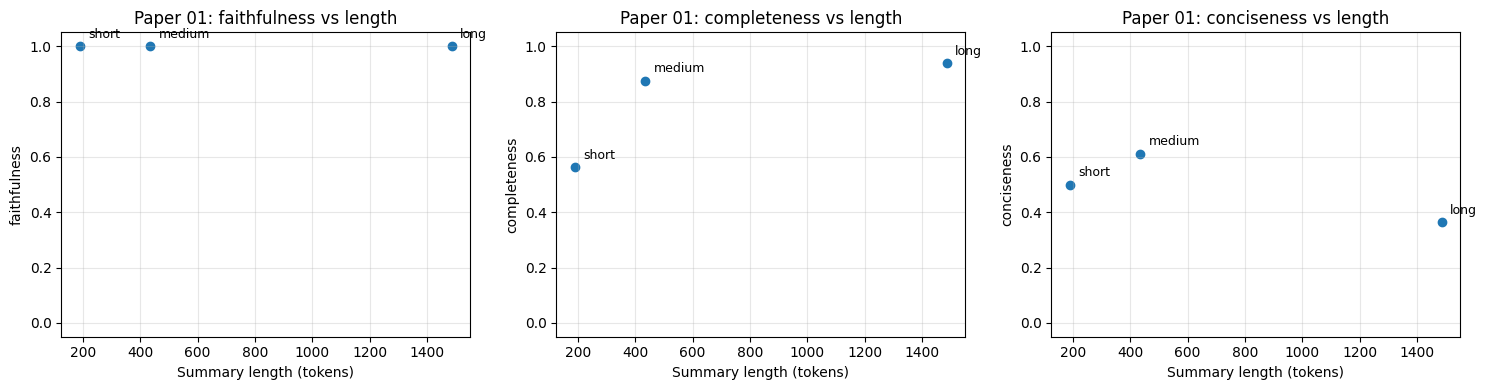

saved /content/work/figures/plots_paper_01.png


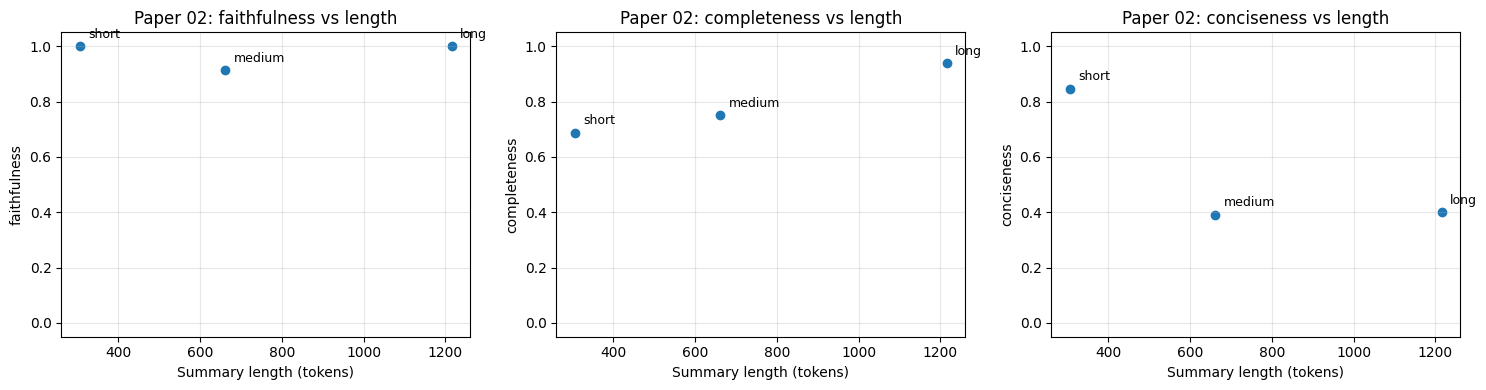

saved /content/work/figures/plots_paper_02.png


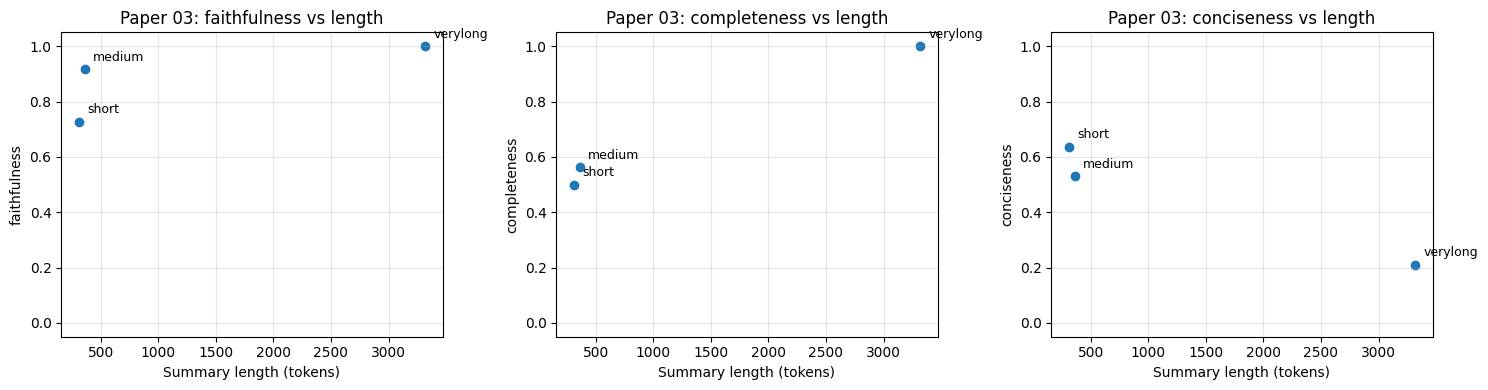

saved /content/work/figures/plots_paper_03.png


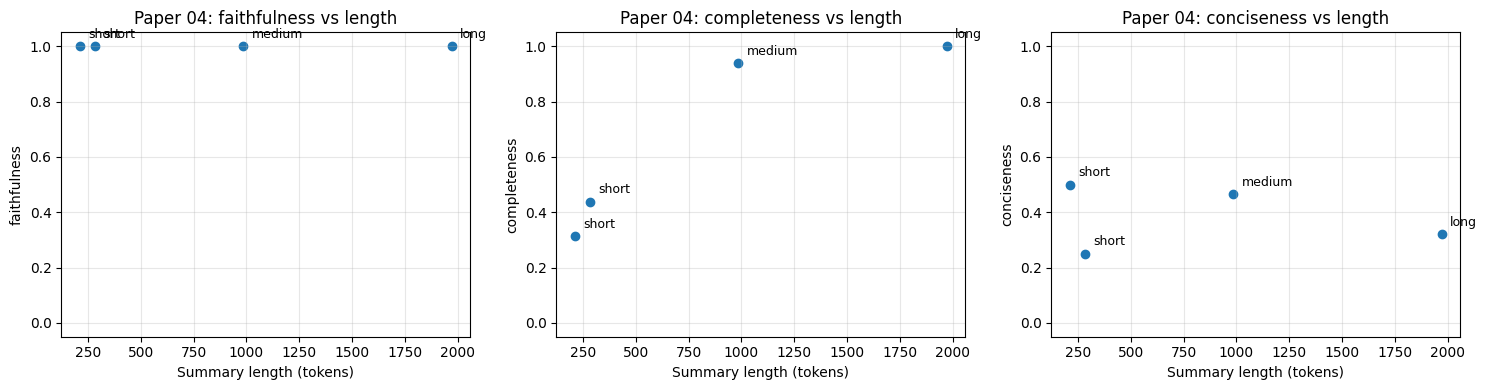

saved /content/work/figures/plots_paper_04.png


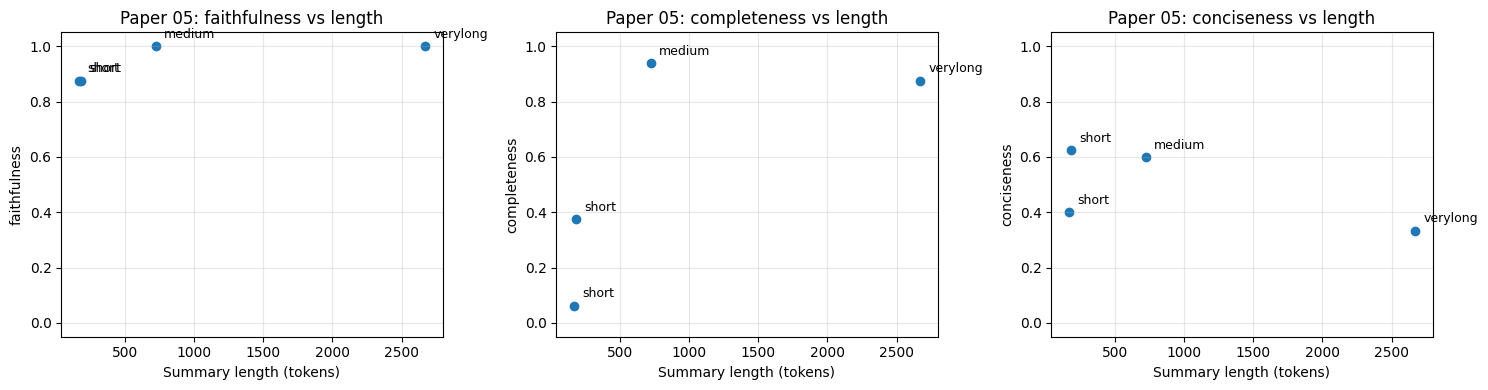

saved /content/work/figures/plots_paper_05.png


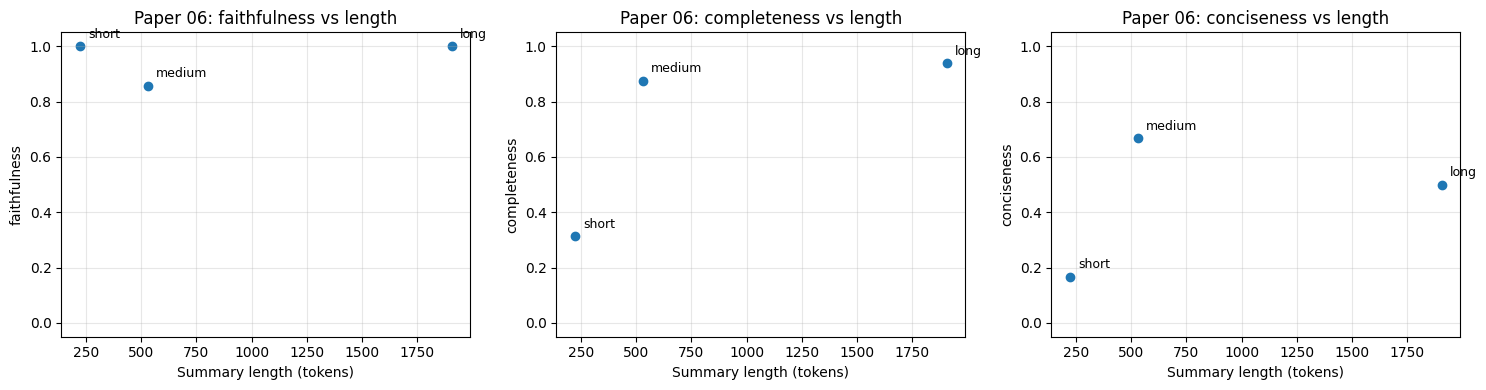

saved /content/work/figures/plots_paper_06.png


In [16]:
import matplotlib.pyplot as plt

for pid, sub in master_df.groupby('paper_id'):
    sub = sub.sort_values('realised_tokens')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ['faithfulness', 'completeness', 'conciseness']):
        ax.scatter(sub['realised_tokens'], sub[col])
        for _, r in sub.iterrows():
            ax.annotate(r['size'], (r['realised_tokens'], r[col]), fontsize=9,
                        xytext=(6, 6), textcoords='offset points')
        ax.set_xlabel('Summary length (tokens)')
        ax.set_ylabel(col)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'Paper {pid}: {col} vs length')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    out = FIGURES_DIR / f'plots_paper_{pid}.png'
    fig.savefig(out, dpi=120)
    plt.show()
    print('saved', out)

## 10. Cross-paper scatter (all summaries together)

Each point is one summary; colour = paper. Useful for spotting a single overall trend after pooling.

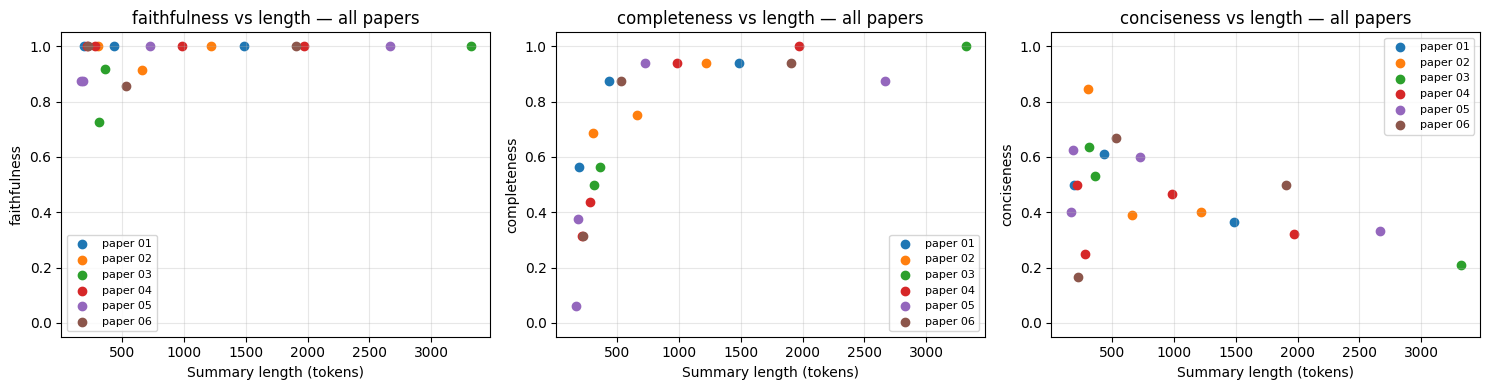

saved /content/work/figures/plots_all_papers.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
papers = sorted(master_df['paper_id'].unique())
cmap = plt.get_cmap('tab10')
for ax, col in zip(axes, ['faithfulness', 'completeness', 'conciseness']):
    for i, pid in enumerate(papers):
        sub = master_df[master_df['paper_id'] == pid]
        ax.scatter(sub['realised_tokens'], sub[col], color=cmap(i), label=f'paper {pid}')
    ax.set_xlabel('Summary length (tokens)')
    ax.set_ylabel(col)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{col} vs length — all papers')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
out = FIGURES_DIR / 'plots_all_papers.png'
fig.savefig(out, dpi=120)
plt.show()
print('saved', out)

## 11. Save results back to Drive

Copies `work/` (cache + results + articles + keyfacts + figures) into Drive so a Colab disconnect can't lose anything. **Always run this cell after the master loop.**

In [18]:
import shutil
dest = PROJECT / 'verbosity_bias_run'
dest.mkdir(parents=True, exist_ok=True)
for sub in ['cache', 'results', 'articles', 'keyfacts', 'figures']:
    src = WORK_DIR / sub
    out = dest / sub
    if not src.exists(): continue
    if out.exists(): shutil.rmtree(out)
    shutil.copytree(src, out)
    print(f'copied {sub}')
print('\nAll results pushed to:', dest)

copied cache
copied results
copied articles
copied keyfacts
copied figures

All results pushed to: /content/drive/MyDrive/summarization/verbosity_bias_run
